In [1]:
# Set some global parameters and paths
import os
import csv
import matplotlib.pyplot as plt
import numpy as np
from math import log

DEBUG = False
RELOAD = False
BASE_DIR = os.path.abspath("")
ROOT_DIR = os.path.abspath(os.path.join(BASE_DIR, '../../'))
EXPERIMENTS_DIR = os.path.join(BASE_DIR, 'experiments')
RESULT_DIR = os.path.join(ROOT_DIR, 'results/lumi_mixer/cases')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

if DEBUG:
    print("Base Directory:", BASE_DIR)
    print("Root Directory:", ROOT_DIR)
    print("Experiments Directory:", EXPERIMENTS_DIR)
    print("Data Directory:", RESULT_DIR)
    print("Output Directory:", OUTPUT_DIR)

# Open an experiment, read the information there

Each experiment is a CSV file with headers reflecting the parameters used to
create the case files.

In [2]:
def read_experiment_file(experiment_name) -> list:
    """
    Read the experiment file and return a list of experiments with their
    parameters.

    Args:
        file_path (str): Path to the experiment CSV file.
    Returns:
        list: List of dictionaries, each representing an experiment with its
        parameters.
    """
    file_path = os.path.join(EXPERIMENTS_DIR, experiment_name)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Experiment file not found: {file_path}")

    # Read the CSV file and parse its contents
    with open(os.path.join(file_path), 'r') as file:
        reader = csv.DictReader(file, delimiter=',', skipinitialspace=True)
        tmp = [row for row in reader]

    # Extract experiments and convert types
    experiments = []
    for row in tmp:
        experiment = {}
        for key, value in row.items():
            try:
                experiment[key] = int(value)
            except ValueError:
                try:
                    experiment[key] = float(value)
                except ValueError:
                    if value.lower() in ['true', 'false']:
                        experiment[key] = value.lower() == 'true'
                    else:
                        experiment[key] = value

        # Check if the experiment has been completed and set the status
        if os.path.exists(os.path.join(RESULT_DIR, experiment['case_name'])):
            experiment['status'] = 'done'
        else:
            experiment['status'] = 'pending'

        experiments.append(experiment)

    return experiments


In [3]:
if DEBUG:
    experiment_file = os.path.join(EXPERIMENTS_DIR, 'single_node_capacity.csv')
    experiment = read_experiment_file(experiment_file)
    print(f"Loaded {len(experiment)} experiments.")
    for exp in experiment:
        print(exp)


# Parse the log files to extract the performance metrics

In [4]:
def read_rt_stats_from_log(experiment: dict) -> list:
    """
    Read the runtime statistics from the log file.
    The runtime statistics will be stored in the experiment dictionary
    under the key 'runtimes'.

    Args:
        log_path (str): Path to the log file.
    """
    log_path = os.path.join(RESULT_DIR, experiment['case_name'],
                            experiment['case_name'] + '.log')

    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found: {log_path}")

    with open(log_path, 'r') as file:
        lines = file.readlines()

    # Look for the pattern
    # `------Runtime statistics------` followed by an empty line
    # Then read the following table until an empty line is found

    start_index = None
    for i, line in enumerate(lines):
        if '------Runtime statistics------' in line:
            start_index = i + 2  # Skip the next empty line
            break
    if start_index is None:
        raise ValueError("Runtime statistics section not found in log file.")

    end_index = start_index
    while end_index < len(lines) and lines[end_index].strip():
        end_index += 1

    # Extract the relevant lines
    stats_lines = lines[start_index:end_index]

    # Parse the statistics lines into a structured format
    header = ["Region name", "Total time", "Avg time", "Range +/-"]

    data = {}
    for line in stats_lines[2:]:
        parts = line.strip().split()
        if len(parts) >= 4:
            region_name = " ".join(parts[:-3])
            total_time = float(parts[-3])
            avg_time = float(parts[-2])
            range_plus_minus = float(parts[-1])

            data[region_name] = {
                header[1]: total_time,
                header[2]: avg_time,
                header[3]: range_plus_minus
            }
    experiment['runtimes'] = data


In [5]:
# Parse the log files to extract the performance metrics
if DEBUG:
    read_rt_stats_from_log(experiment[1])
    print("Parsed Statistics Data:")
    for region, times in experiment[1]['runtimes'].items():
        print(f"Region: '{region}'")
        for key, value in times.items():
            print(f"   '{key}': {value}")


In [6]:
def extract_times(experiment: list,
                  region: str,
                  measure: str = 'Avg time') -> np.ndarray:
    """
    Extract specific timing data from the experiment's runtimes.

    Args:
        experiment (list): The experiment dictionary containing runtimes.
        region (str): The region name to extract.
        measure (str): The measure to extract (default is 'Avg Time').
                       Possible values:  'Total time' 'Avg. time' 'Range +/-'

    Returns:
        np.ndarray: Array of extracted times.
    """

    result = np.array([])
    for exp in experiment:
        if exp['status'] != 'done':
            continue

        if 'runtimes' not in exp:
            read_rt_stats_from_log(exp)

        if 'runtimes' in exp and region in exp['runtimes']:
            result = np.append(result, exp['runtimes'][region][measure])

    return result

# Single node capacity analysis

Here we have investigated the effect of adding more elements onto a single node
of LUMi. This will help us choose the right mesh size for a given problem.

In [7]:
single_node_capacity = read_experiment_file('single_node_capacity.csv')

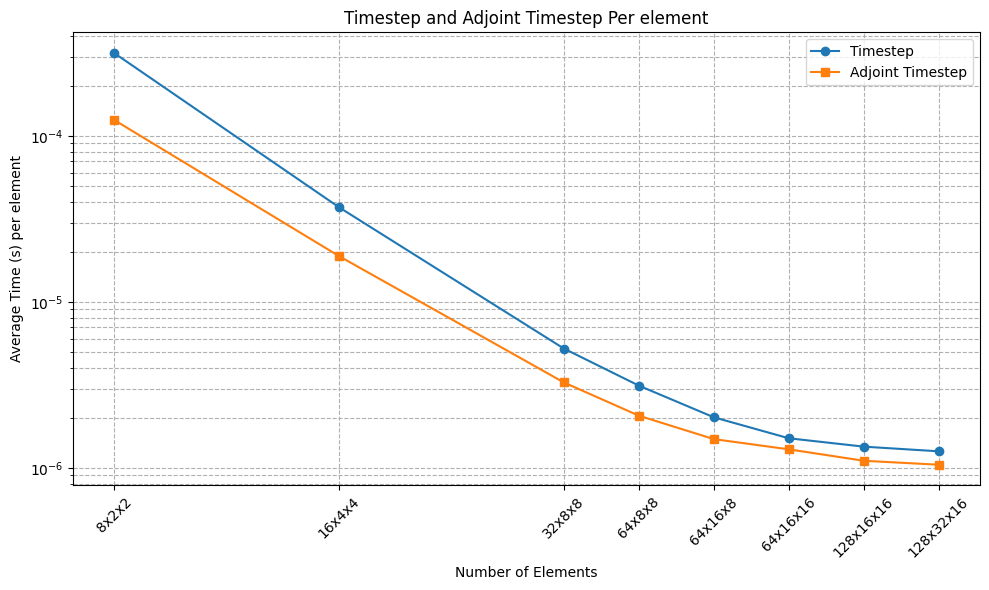

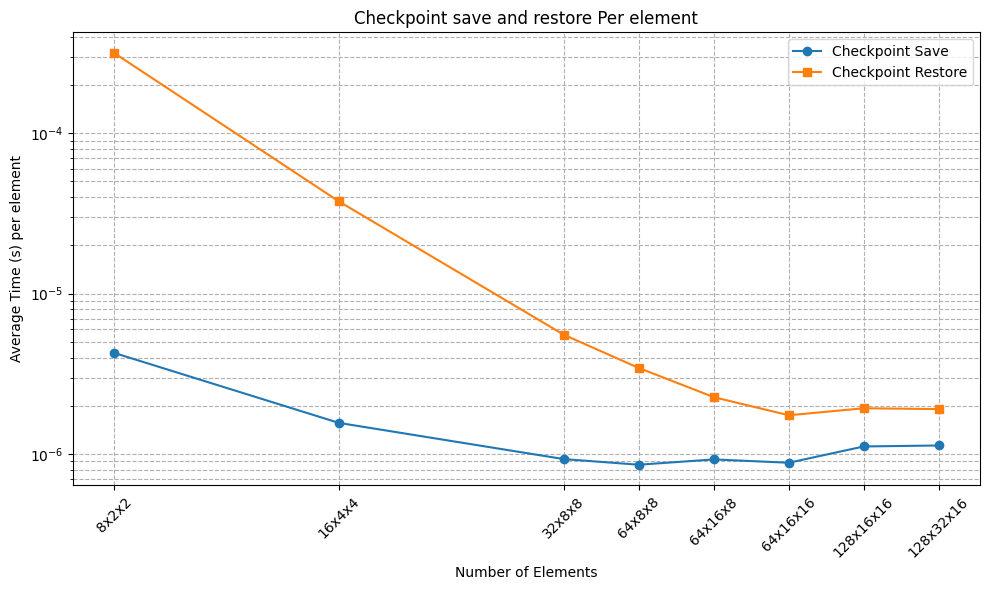

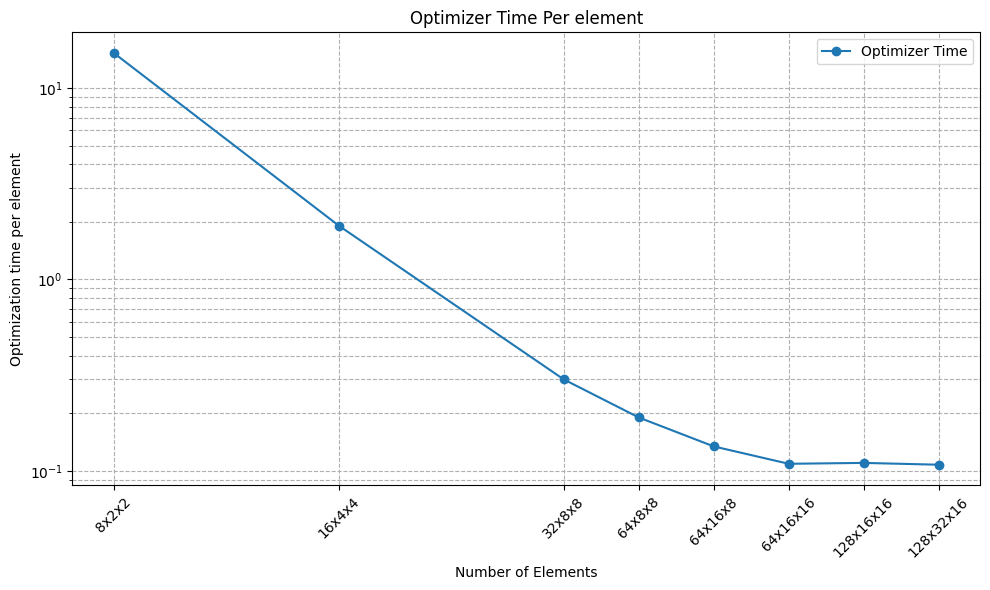

In [8]:
# Plot the timestep and adjoint timestep as a function of the number of elements
num_elements = np.array([])
timestep = np.array([])
adjoint_timestep = np.array([])
checkpoint_save = np.array([])
checkpoint_restore = np.array([])
optimizer_time = np.array([])

num_elements = np.array([
    exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in single_node_capacity
    if exp['status'] == 'done'
])
mesh_labels = np.array([
    f"{exp['Nx']}x{exp['Ny']}x{exp['Nz']}" for exp in single_node_capacity
    if exp['status'] == 'done'
])

timestep = extract_times(single_node_capacity, 'Time-Step')
adjoint_timestep = extract_times(single_node_capacity, 'Time-Step Adjoint')
checkpoint_save = extract_times(single_node_capacity, 'Checkpoint save')
checkpoint_restore = extract_times(single_node_capacity, 'Checkpoint restore')
optimizer_time = extract_times(single_node_capacity, 'Optimizer iteration 0', 'Total time') + \
                 extract_times(single_node_capacity, 'Optimizer iteration', 'Total time')

plt.figure(figsize=(10, 6))
plt.plot(num_elements, timestep / num_elements, marker='o', label='Timestep')
plt.plot(num_elements,
         adjoint_timestep / num_elements,
         marker='s',
         label='Adjoint Timestep')

#  Set xscale to be log2 and yscale to be log10
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Average Time (s) per element')
plt.xticks(num_elements, mesh_labels, rotation=45)
plt.title('Timestep and Adjoint Timestep Per element')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()

plt.figure(figsize=(10, 6))
plt.plot(num_elements,
         checkpoint_save / num_elements,
         marker='o',
         label='Checkpoint Save')
plt.plot(num_elements,
         checkpoint_restore / num_elements,
         marker='s',
         label='Checkpoint Restore')

#  Set xscale to be log2 and yscale to be log10
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Average Time (s) per element')
plt.xticks(num_elements, mesh_labels, rotation=45)
plt.title('Checkpoint save and restore Per element')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()

plt.figure(figsize=(10, 6))
plt.plot(num_elements,
         optimizer_time / num_elements,
         marker='o',
         label='Optimizer Time')

#  Set xscale to be log2 and yscale to be log10
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Elements')
plt.ylabel('Optimization time per element')
plt.xticks(num_elements, mesh_labels, rotation=45)
plt.title('Optimizer Time Per element')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

# Checkpoints

We know a limiting factor is the checkpoints. This section will investigate the
behaviour as we use more checkpoints for a couple of mesh sizes.

In [9]:
checkpoint_count = read_experiment_file('memory_checkpoints.csv')

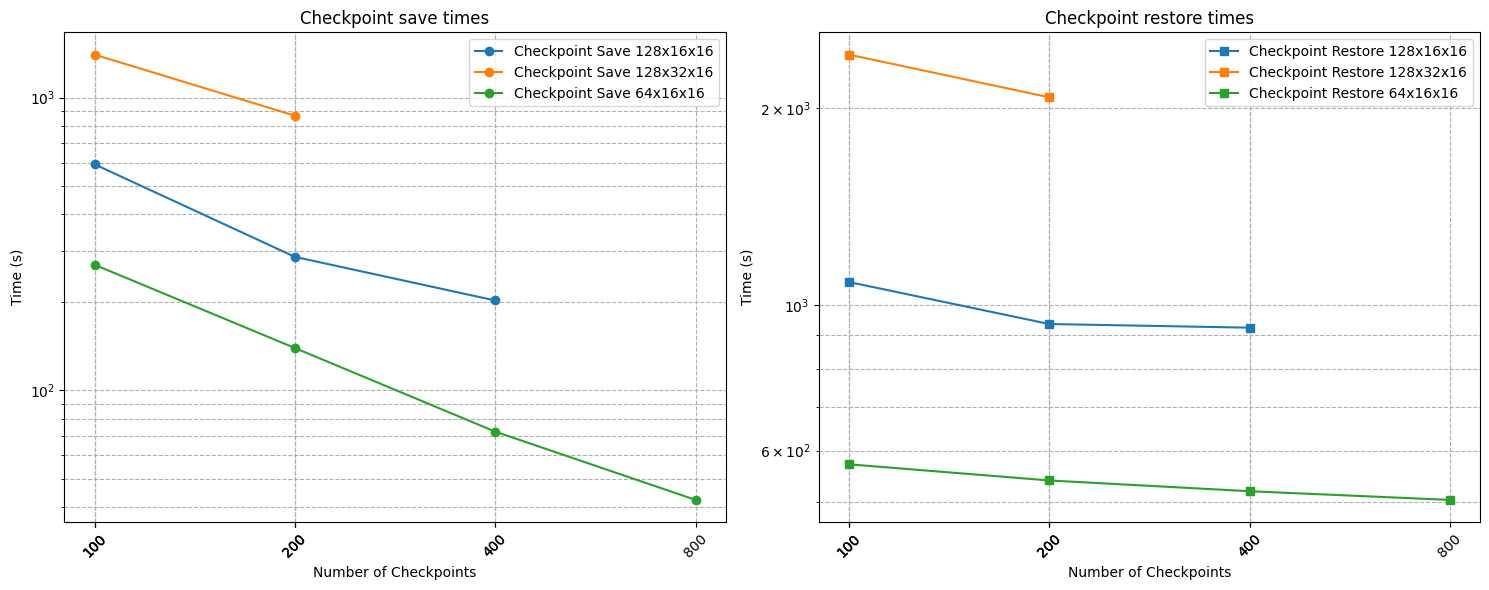

In [10]:
# Plot the checkpoint save and restore times as a function of the number of
# checkpoints.

num_memory = np.array(
    [exp['N_memory'] for exp in checkpoint_count if exp['status'] == 'done'])
checkpoint_save = extract_times(checkpoint_count, 'Checkpoint save',
                                'Total time')
checkpoint_restore = extract_times(checkpoint_count, 'Checkpoint restore',
                                   'Total time')

# Get the mesh size for the labels and group by mesh size
mesh_size = np.array([
    f"{exp['Nx']}x{exp['Ny']}x{exp['Nz']}" for exp in checkpoint_count
    if exp['status'] == 'done'
])
mesh_labels = np.array(list(set(mesh_size)))

# Plot the checkpoint save and restore times in two subfigures grouped by
# mesh size
[fig_checkpoint, ax_checkpoint] = plt.subplots(1, 2, figsize=(15, 6))

for mesh in mesh_labels:
    mask = mesh_size == mesh
    ax_checkpoint[0].plot(num_memory[mask],
                          checkpoint_save[mask],
                          marker='o',
                          label=f'Checkpoint Save {mesh}')
    ax_checkpoint[1].plot(num_memory[mask],
                          checkpoint_restore[mask],
                          marker='s',
                          label=f'Checkpoint Restore {mesh}')

for i, ax in enumerate(ax_checkpoint):
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=10)
    ax.set_xlabel('Number of Checkpoints')
    ax.set_ylabel('Time (s)')
    ax.set_xticks(num_memory)
    ax.set_xticklabels(num_memory, rotation=45)
    if i == 0:
        ax.set_title('Checkpoint save times')
    else:
        ax.set_title('Checkpoint restore times')
    ax.legend()
    ax.grid(True, which="both", ls="--")

plt.tight_layout()

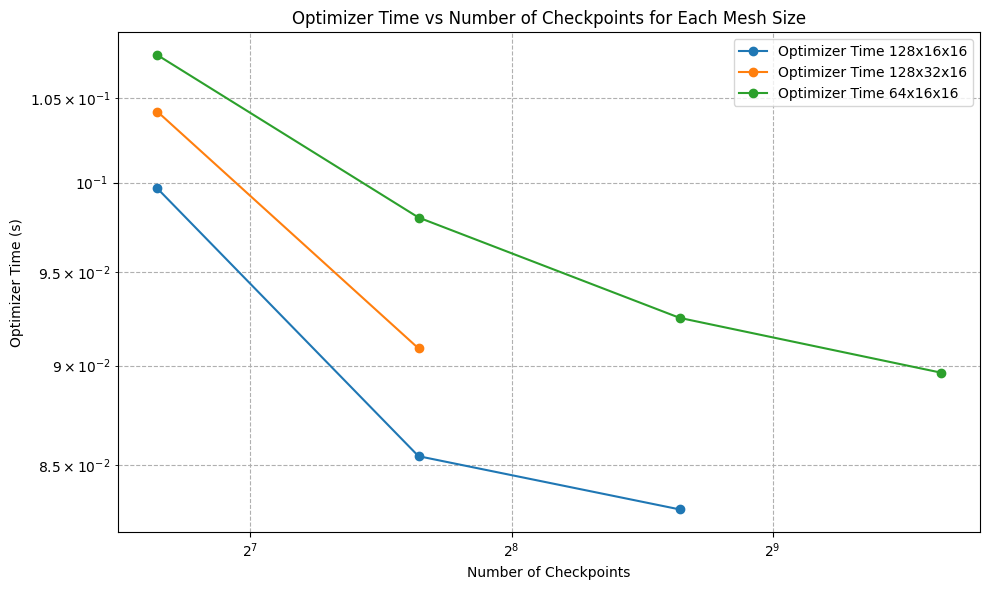

In [11]:
checkpoint_optimizer_time = extract_times(
    checkpoint_count, 'Optimizer iteration 0', 'Total time') + extract_times(
        checkpoint_count, 'Optimizer iteration', 'Total time')
checkpoint_num_elements = np.array([
    exp['Nx'] * exp['Ny'] * exp['Nz'] for exp in checkpoint_count
    if exp['status'] == 'done'
])

plt.figure(figsize=(10, 6))

for mesh in mesh_labels:
    mask = mesh_size == mesh
    plt.plot(num_memory[mask],
             checkpoint_optimizer_time[mask] / checkpoint_num_elements[mask],
             marker='o',
             label=f'Optimizer Time {mesh}')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of Checkpoints')
plt.ylabel('Optimizer Time (s)')
plt.title('Optimizer Time vs Number of Checkpoints for Each Mesh Size')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

# Initial Weak scaling

From the above it seems the 128x16x16 with 400 checkpoints is a good candidate
for a weak scaling study. To narrow down the mesh size we can do a weak scaling
study with a few different aspect ratios and checkpoint amounts to see how they
behave as the network is stressed.


In [12]:
aspect_checkpoint_scaling = read_experiment_file(
    'aspect_checkpoint_scaling.csv')

In [13]:
for exp in aspect_checkpoint_scaling:
    if exp['status'] != 'done':
        continue

    # Determine the base aspect ratio based on the number elements
    num_elements = exp['Nx'] * exp['Ny'] * exp['Nz']
    if num_elements < 64 * 16 * 16:
        base_aspect = 8
    elif num_elements < 128 * 32 * 32:
        base_aspect = 16
    elif num_elements < 256 * 64 * 64:
        base_aspect = 32
    elif num_elements < 512 * 128 * 128:
        base_aspect = 64

    aspect = [
        int(log(exp["Nx"] / base_aspect, 2) - 1),
        int(log(exp["Ny"] / base_aspect, 2) + 1),
        int(log(exp["Nz"] / base_aspect, 2) + 1)
    ]
    exp['aspect'] = f'{aspect[0]}:{aspect[1]}:{aspect[2]}'

unique_aspects = list(
    set(exp['aspect'] for exp in aspect_checkpoint_scaling
        if exp['status'] == 'done'))
unique_checkpoints = list(
    set(exp['N_memory'] for exp in aspect_checkpoint_scaling
        if exp['status'] == 'done'))
unique_nodes = list(
    set(exp['nodes'] for exp in aspect_checkpoint_scaling
        if exp['status'] == 'done'))
for n_checkpoints in sorted(unique_checkpoints):
    print(f"\nNumber of Checkpoints: {n_checkpoints}")
    for n_nodes in sorted(unique_nodes):
        for aspect in sorted(unique_aspects):

            # Filter experiments for this combination
            exp = [
                exp for exp in aspect_checkpoint_scaling
                if exp['status'] == 'done' and exp['N_memory'] == n_checkpoints
                and exp['nodes'] == n_nodes and exp['aspect'] == aspect
            ]
            if not exp:
                continue
            time = extract_times(exp, 'Optimizer iteration 0', 'Total time') + \
                   extract_times(exp, 'Optimizer iteration', 'Total time')
            time = time[0] / (exp[0]['Nx'] * exp[0]['Ny'] * exp[0]['Nz'])
            print(f"  Nodes: {n_nodes}, Aspect: {aspect}, Time: {time:.2e} s")



Number of Checkpoints: 200
  Nodes: 1, Aspect: 1:2:2, Time: 9.10e-02 s
  Nodes: 1, Aspect: 2:1:2, Time: 9.17e-02 s
  Nodes: 1, Aspect: 2:2:1, Time: 9.09e-02 s

Number of Checkpoints: 400
  Nodes: 1, Aspect: 1:1:2, Time: 8.49e-02 s
  Nodes: 1, Aspect: 1:2:1, Time: 8.51e-02 s
  Nodes: 1, Aspect: 2:1:1, Time: 8.29e-02 s
  Nodes: 2, Aspect: 1:2:2, Time: 5.07e-02 s
  Nodes: 2, Aspect: 2:1:2, Time: 4.78e-02 s
  Nodes: 2, Aspect: 2:2:1, Time: 5.29e-02 s
  Nodes: 4, Aspect: 1:1:1, Time: 3.09e-02 s

Number of Checkpoints: 800
  Nodes: 1, Aspect: 1:1:1, Time: 8.96e-02 s
  Nodes: 2, Aspect: 1:1:2, Time: 4.89e-02 s
  Nodes: 2, Aspect: 1:2:1, Time: 4.87e-02 s
  Nodes: 2, Aspect: 2:1:1, Time: 4.83e-02 s
  Nodes: 4, Aspect: 1:2:2, Time: 2.72e-02 s
  Nodes: 4, Aspect: 2:1:2, Time: 2.99e-02 s
  Nodes: 4, Aspect: 2:2:1, Time: 3.23e-02 s


# The actual weak scaling study

We have determined so far that a mesh size of 64x16x16 with 800 checkpoints is
the best candidate for a weak scaling study. 
However, we have not enabled the parallel filesystem. For now we go with this
and tune the file system striping to this case.

- Stripe count: 1, stripe size: 1MB - falls bellow 60% at 8 nodes.
- 

In [37]:
weak_scaling_experiments = read_experiment_file('weak_scaling.csv')

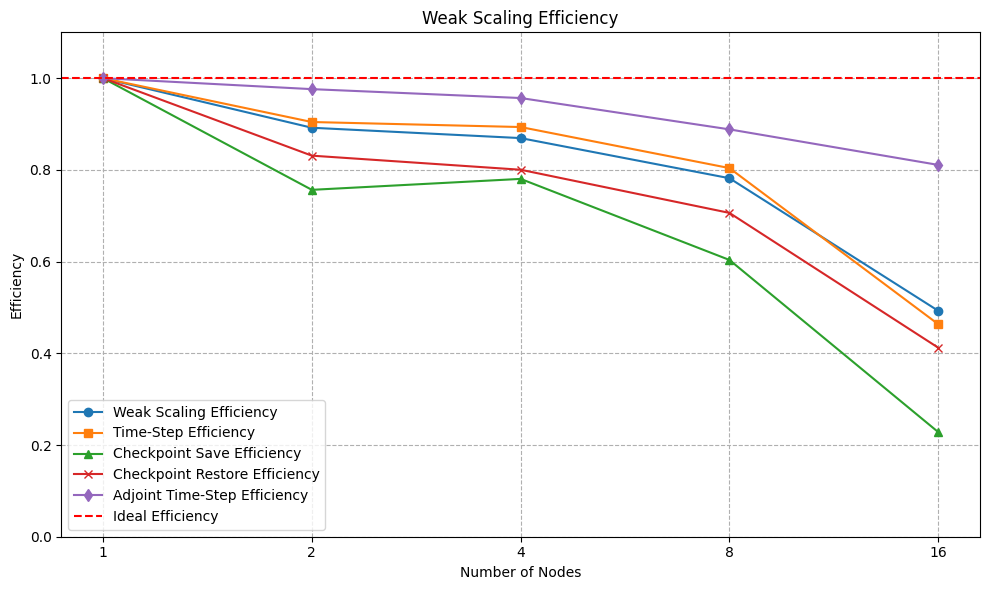

In [38]:
weak_scaling_nodes = np.array([
    exp['nodes'] for exp in weak_scaling_experiments if exp['status'] == 'done'
])
weak_scaling_times = extract_times(
    weak_scaling_experiments,
    'Optimizer iteration 0', 'Total time') + extract_times(
        weak_scaling_experiments, 'Optimizer iteration', 'Total time')
weak_scaling_time_step = extract_times(weak_scaling_experiments, 'Time-Step')
weak_scaling_time_step_adj = extract_times(weak_scaling_experiments,
                                           'Time-Step Adjoint')
weak_scaling_checkpoint_save = extract_times(weak_scaling_experiments,
                                             'Checkpoint save')
weak_scaling_checkpoint_restore = extract_times(weak_scaling_experiments,
                                                'Checkpoint restore')

# Sort the nodes and times by nodes
sorted_indices = np.argsort(weak_scaling_nodes)
weak_scaling_nodes = weak_scaling_nodes[sorted_indices]
weak_scaling_times = weak_scaling_times[sorted_indices]
weak_scaling_time_step = weak_scaling_time_step[sorted_indices]

plt.figure(figsize=(10, 6))
plt.plot(weak_scaling_nodes,
         weak_scaling_times[0] / weak_scaling_times,
         marker='o',
         label='Weak Scaling Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_time_step[0] / weak_scaling_time_step,
         marker='s',
         label='Time-Step Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_checkpoint_save[0] / weak_scaling_checkpoint_save,
         marker='^',
         label='Checkpoint Save Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_checkpoint_restore[0] / weak_scaling_checkpoint_restore,
         marker='x',
         label='Checkpoint Restore Efficiency')
plt.plot(weak_scaling_nodes,
         weak_scaling_time_step_adj[0] / weak_scaling_time_step_adj,
         marker='d',
         label='Adjoint Time-Step Efficiency')
plt.xscale('log', base=2)
plt.xlabel('Number of Nodes')
plt.ylabel('Efficiency')
plt.xticks(weak_scaling_nodes, weak_scaling_nodes)
plt.title('Weak Scaling Efficiency')
plt.ylim(0, 1.1)
plt.axhline(y=1.0, color='r', linestyle='--', label='Ideal Efficiency')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()